# Part 1-Preprocessing

In [1]:

#Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid") 
#Reading the Data set into the python file
df = pd.read_csv("ABC Company.xlsx - Sheet1.csv")
#Displaying the data set
print(df.head())

            Name            Team  Number Position  Age  Height  Weight  \
0  Avery Bradley  Boston Celtics       0       PG   25  06-Feb     180   
1    Jae Crowder  Boston Celtics      99       SF   25  06-Jun     235   
2   John Holland  Boston Celtics      30       SG   27  06-May     205   
3    R.J. Hunter  Boston Celtics      28       SG   22  06-May     185   
4  Jonas Jerebko  Boston Celtics       8       PF   29  06-Oct     231   

             College     Salary  
0              Texas  7730337.0  
1          Marquette  6796117.0  
2  Boston University        NaN  
3      Georgia State  1148640.0  
4                NaN  5000000.0  


In [2]:
#Part 1-Preprocessing
df['Height']=np.random.randint(150,180,size=(len(df)))
print(df.isna().sum()) #Number of null values in each column

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64


# Part 2 -Analysis Tasks

In [3]:
no_employees=df["Team"].value_counts()
print("No of Employees per Team=\n",no_employees)

No of Employees per Team=
 Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
New York Knicks           16
Milwaukee Bucks           16
Brooklyn Nets             15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Denver Nuggets            15
Washington Wizards        15
Miami Heat                15
Charlotte Hornets         15
Atlanta Hawks             15
San Antonio Spurs         15
Houston Rockets           15
Boston Celtics            15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Sacramento Kings          15
Phoenix Suns              15
Los Angeles Lakers        15
Los Angeles Clippers      15
Golden State Warriors     15
Toronto Raptors           15
Philadelphia 76ers        15
Dallas Mavericks          15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64


In [4]:
#Percentage split
print("Percentage Split=\n",no_employees/len(df)*100)

Percentage Split=
 Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
New York Knicks           3.493450
Milwaukee Bucks           3.493450
Brooklyn Nets             3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Miami Heat                3.275109
Charlotte Hornets         3.275109
Atlanta Hawks             3.275109
San Antonio Spurs         3.275109
Houston Rockets           3.275109
Boston Celtics            3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Sacramento Kings          3.275109
Phoenix Suns              3.275109
Los Angeles Lakers        3.275109
Los Angeles Clippers      3.275109
Golden State Warriors     3.275109
Toronto Raptors           3.275109
Philadelphia 76ers        3.275109
Dallas Mavericks          3.275

In [5]:
position=df["Position"].value_counts()
print("Segragation of Employee based on Position=\n",position)

Segragation of Employee based on Position=
 Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


In [6]:
df["Age Group"]=pd.cut(df["Age"],bins=[20,30,40,50,60],labels=["20-30","30-40","40-50","50-60" ])
age_group=df["Age Group"].value_counts()
print(age_group)

Age Group
20-30    346
30-40     91
40-50      0
50-60      0
Name: count, dtype: int64


In [7]:
team_salary=df.groupby("Team")["Salary"].sum()
position_salary=df.groupby("Position")["Salary"].sum()
print("Team with highest salary:", team_salary.idxmax())
print("Position with highest salary:", position_salary.idxmax())

Team with highest salary: Cleveland Cavaliers
Position with highest salary: C


In [8]:
correlation=df["Age"].corr(df["Salary"])
print("Correaltion:",correlation)

Correaltion: 0.21400941226570971


# Part 3-Visualization Tasks

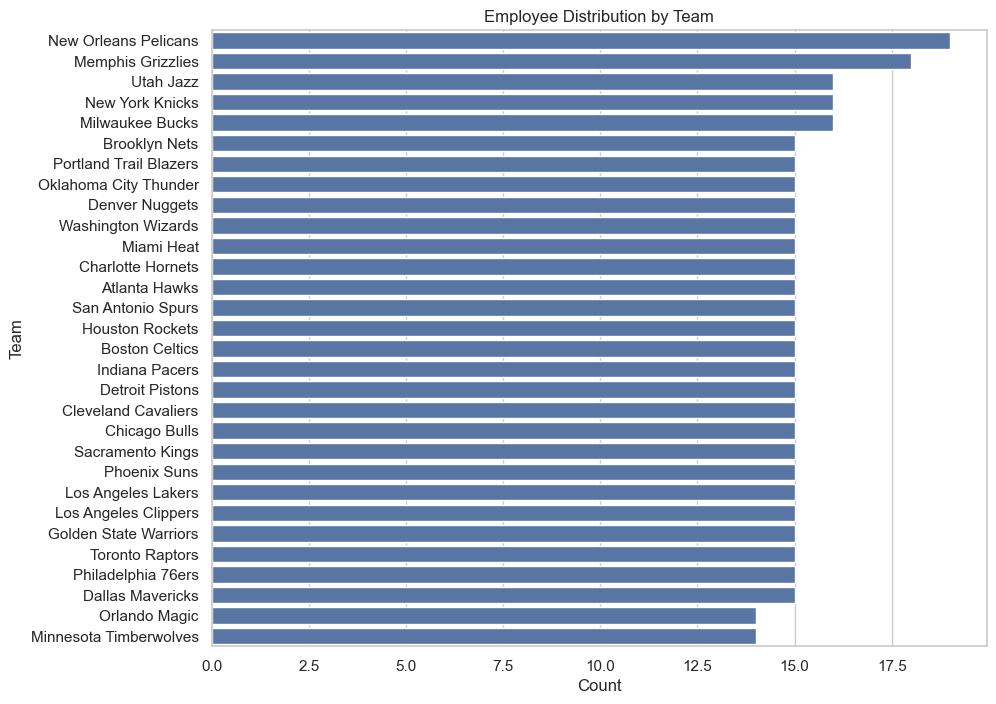

In [9]:
# Employee distribuaiton by Team
plt.figure(figsize=(10,8))

sns.countplot(
    y="Team", 
    data=df, 
    order=df["Team"].value_counts().index
)

plt.title("Employee Distribution by Team")
plt.xlabel("Count")
plt.ylabel("Team")

plt.show()

Employee distribution across teams is largely balanced, with most teams having similar counts. A few teams like New Orleans Pelicans and Memphis Grizzlies have slightly higher numbers, while teams such as Minnesota Timberwolves and Orlando Magic have slightly fewer, indicating minor variations in team sizes.

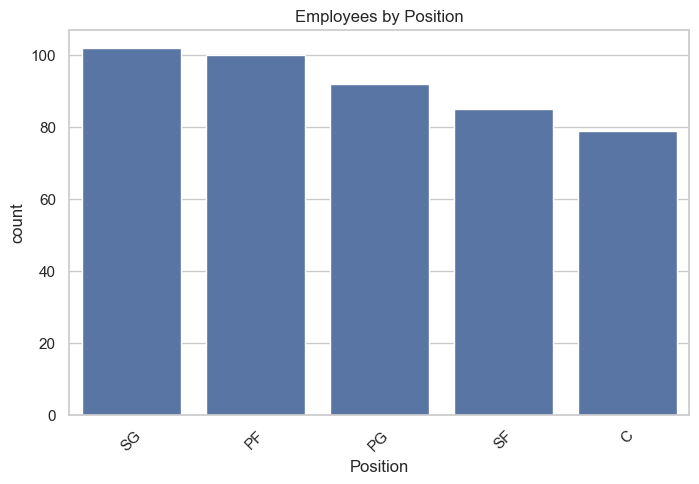

In [10]:
# Employees by position
plt.figure(figsize=(8,5))
sns.countplot(x="Position", data=df, order=df["Position"].value_counts().index)

plt.title("Employees by Position")
plt.xticks(rotation=45)
plt.show()

Employee distribution across positions is fairly balanced, with SG and PF having slightly higher counts, while C has comparatively fewer employees, indicating minor variations across roles.

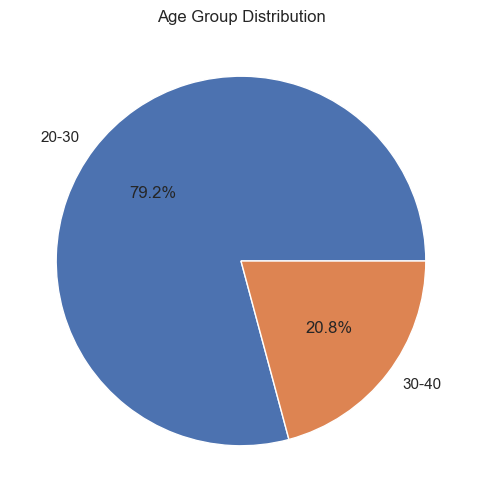

In [14]:
# Age  Group Distribaution
age_group = df["Age Group"].value_counts()

# Remove groups with 0 count
age_group = age_group[age_group > 0]

plt.figure(figsize=(6,6))
age_group.plot.pie(autopct='%1.1f%%')

plt.title("Age Group Distribution")
plt.ylabel("")
plt.show()

The majority of employees fall within the 20–30 age group (~79%), while the remaining (~21%) are in the 30–40 range, indicating a predominantly young workforce.

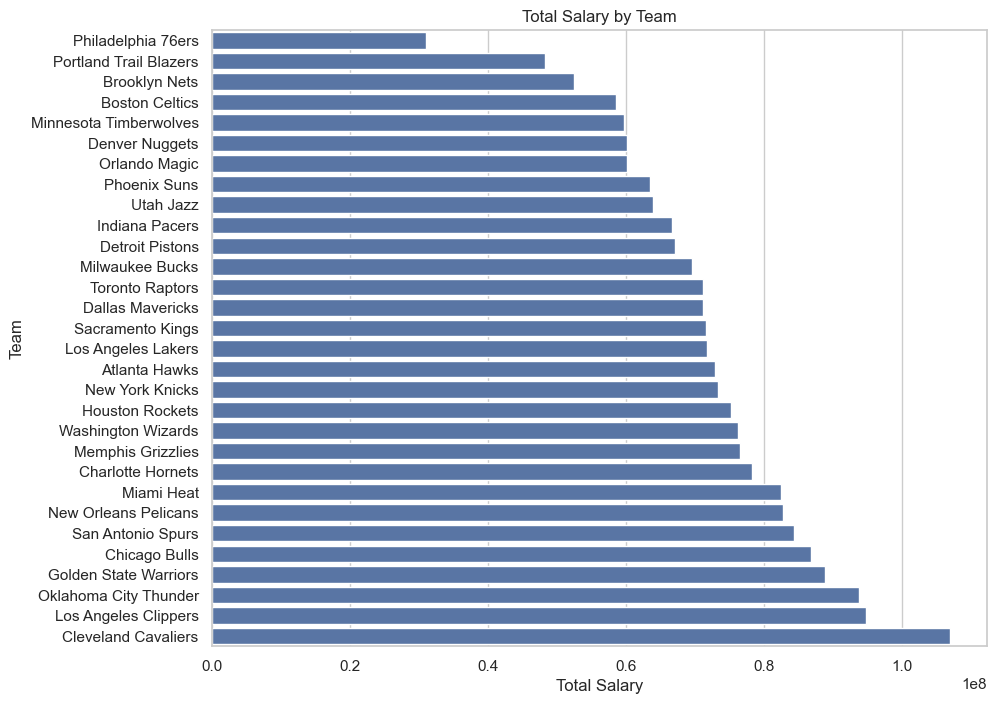

In [12]:
team_salary = df.groupby("Team")["Salary"].sum().sort_values()

plt.figure(figsize=(10,8))

sns.barplot(
    x=team_salary.values,
    y=team_salary.index
)

plt.title("Total Salary by Team")
plt.xlabel("Total Salary")
plt.ylabel("Team")

plt.show()

Salary expenditure varies across teams, with Cleveland Cavaliers having the highest total salary, while teams like Philadelphia 76ers have comparatively lower expenditure, indicating differences in team payroll distribution.

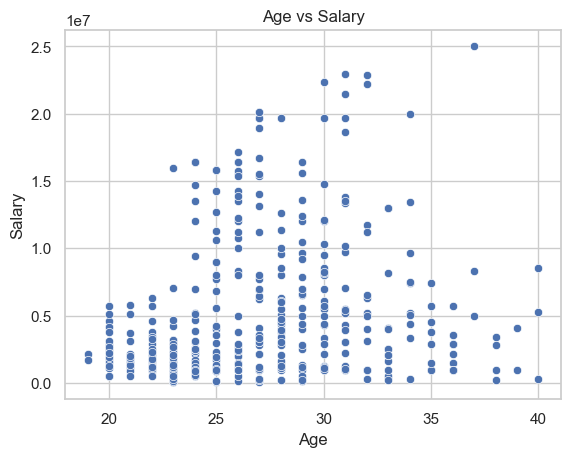

In [13]:
sns.scatterplot(x="Age", y="Salary", data=df)
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

The scatter plot shows a slight positive relationship between age and salary, with salaries generally increasing with age, though there is considerable variation across all age groups.